# ForecastLab

---

## Bike Sharing Demand Forecasting

---

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-001 |
| **Eksperimen** | EXP-006 |
| **Nama Eksperimen** | Baseline Forecasting |
| **Dataset** | featured_data.csv (output EXP-004) |
| **Tujuan Notebook** | Membangun model baseline sebagai pembanding seluruh model Machine Learning |
| **Tanggal Pengerjaan** | Juli 2026 |
| **Versi Notebook** | 1.0.0 |
| **Author** | GAKUSEI Najib |
| **Prasyarat** | EXP-001 s.d. EXP-005 ✅ |

---

## Daftar Isi

1. [Tujuan Eksperimen](#1-tujuan-eksperimen)
2. [Import Library](#2-import-library)
3. [Load Dataset](#3-load-dataset)
4. [Train-Test Split (Time Series)](#4-train-test-split-time-series)
5. [Naive Forecast](#5-naive-forecast)
6. [Moving Average Forecast](#6-moving-average-forecast)
7. [Seasonal Naive Forecast (Lag 24)](#7-seasonal-naive-forecast-lag-24)
8. [Perbandingan Baseline](#8-perbandingan-baseline)
9. [Kesimpulan & Next Step](#9-kesimpulan--next-step)

---

## 1. Tujuan Eksperimen

### Tujuan

Membangun model baseline sederhana sebagai pembanding utama bagi seluruh model machine learning berikutnya.

---

### Hipotesis

> Model sederhana mampu memberikan gambaran awal mengenai tingkat kesulitan forecasting pada dataset.

---

### Model Baseline yang Dibuat

| Model | Konsep |
|-------|--------|
| **Naive Forecast** | Prediksi $\hat{y}_{t+1} = y_t$ (nilai sekarang = nilai sebelumnya) |
| **Moving Average (3 jam)** | Prediksi = rata-rata 3 jam terakhir |
| **Seasonal Naive (Lag 24)** | Prediksi = nilai pada jam yang sama kemarin |

---

### Acceptance Criteria

| Kriteria | Keterangan |
|----------|------------|
| Minimal dua baseline selesai | Naive + Moving Average + Seasonal Naive |
| Seluruh metrik dihitung | MAE, RMSE, MAPE |
| Hasil divisualisasikan | Grafik prediksi vs aktual |

---

## 2. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('Library berhasil diimport.')

Library berhasil diimport.


---

## 3. Load Dataset

Dataset yang digunakan adalah `featured_data.csv` hasil dari EXP-004.

In [2]:
INPUT_PATH = '../data/featured_data.csv'

df = pd.read_csv(INPUT_PATH)
df['dteday'] = pd.to_datetime(df['dteday'])
df = df.sort_values(by=['dteday', 'hr']).reset_index(drop=True)

print(f'Dataset berhasil dimuat: {INPUT_PATH}')
print(f'Dimensi: {df.shape[0]:,} baris x {df.shape[1]} kolom')

Dataset berhasil dimuat: ../data/featured_data.csv
Dimensi: 17,379 baris x 45 kolom


---

## 4. Train-Test Split (Time Series)

Karena data bersifat time series, split dilakukan secara **kronologis**: data 2011 digunakan sebagai training, data 2012 sebagai testing.

In [3]:
# Split kronologis
train = df[df['yr'] == 0].copy()   # 2011
test  = df[df['yr'] == 1].copy()   # 2012

y_train = train['cnt'].values
y_test  = test['cnt'].values

print(f'Train size: {len(train):,} ({train["dteday"].min().date()} s.d. {train["dteday"].max().date()})')
print(f'Test size : {len(test):,} ({test["dteday"].min().date()} s.d. {test["dteday"].max().date()})')
print(f'Train-Test ratio: {len(train)/len(df)*100:.1f}% - {len(test)/len(df)*100:.1f}%')

Train size: 8,645 (2011-01-01 s.d. 2011-12-31)
Test size : 8,734 (2012-01-01 s.d. 2012-12-31)
Train-Test ratio: 49.7% - 50.3%


### 4.1 Fungsi Evaluasi

Metrik yang digunakan:
- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **MAPE** (Mean Absolute Percentage Error)

In [4]:
def hitung_metrik(y_true, y_pred, nama_model):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    return {'Model': nama_model, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

print('Fungsi evaluasi siap.')

Fungsi evaluasi siap.


---

## 5. Naive Forecast

Naive Forecast mengasumsikan nilai prediksi sama dengan nilai observasi terakhir.

$$\hat{y}_{t+1} = y_t$$

In [5]:
# Naive Forecast: shift 1 jam ke depan
y_pred_naive = np.roll(y_test, 1)
y_pred_naive[0] = y_train[-1]  # isi baris pertama dengan train terakhir

metrik_naive = hitung_metrik(y_test, y_pred_naive, 'Naive Forecast')
print(pd.DataFrame([metrik_naive]).to_string(index=False))

         Model     MAE     RMSE    MAPE
Naive Forecast 80.1782 121.5638 57.6021


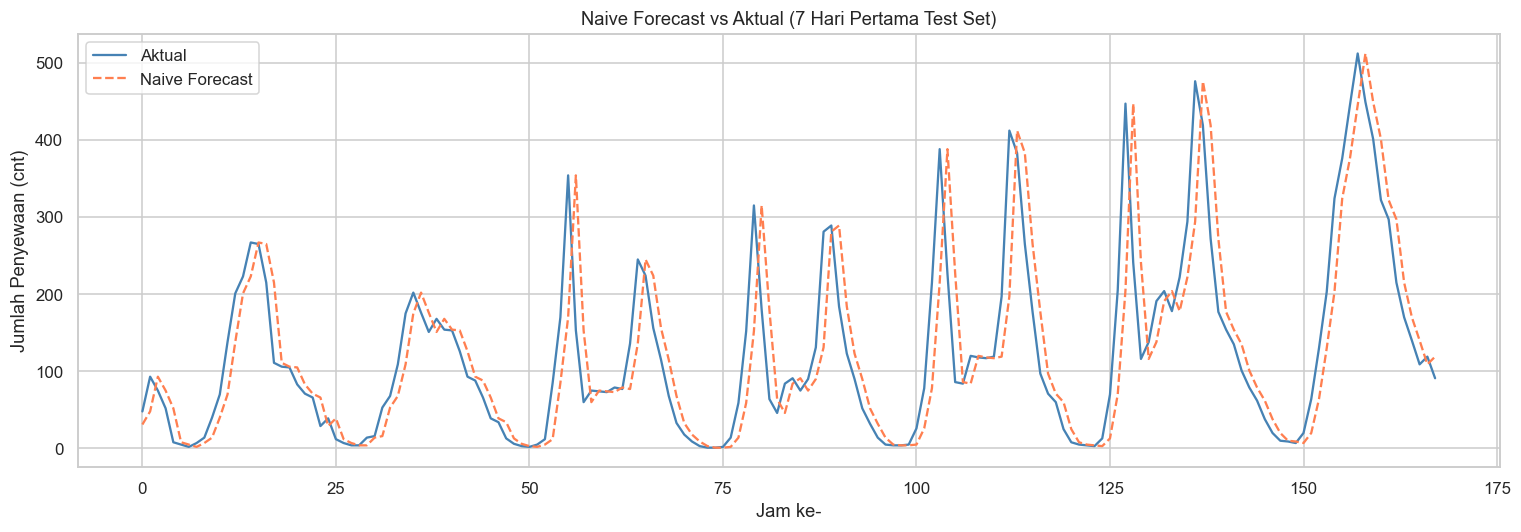

Grafik Naive Forecast tersimpan.


In [6]:
# Visualisasi 7 hari pertama test
hari_tampil = 7 * 24  # 7 jam

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(hari_tampil), y_test[:hari_tampil], label='Aktual', color='steelblue', linewidth=1.5)
ax.plot(range(hari_tampil), y_pred_naive[:hari_tampil], label='Naive Forecast', color='coral', linewidth=1.5, linestyle='--')
ax.set_title('Naive Forecast vs Aktual (7 Hari Pertama Test Set)')
ax.set_xlabel('Jam ke-')
ax.set_ylabel('Jumlah Penyewaan (cnt)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/baseline_01_naive.png', bbox_inches='tight', dpi=110)
plt.show()
print('Grafik Naive Forecast tersimpan.')

---

## 6. Moving Average Forecast

Moving Average memprediksi nilai berdasarkan rata-rata $N$ observasi terakhir.

$$\hat{y}_{t+1} = \frac{1}{N} \sum_{i=0}^{N-1} y_{t-i}$$

In [7]:
def moving_average_forecast(y, window):
    pred = np.full_like(y, np.nan)
    for i in range(len(y)):
        if i < window:
            pred[i] = np.mean(y[:i+1]) if i > 0 else y[0]
        else:
            pred[i] = np.mean(y[i-window:i])
    return pred

y_pred_ma3  = moving_average_forecast(y_test, 3)
y_pred_ma6  = moving_average_forecast(y_test, 6)
y_pred_ma24 = moving_average_forecast(y_test, 24)

metrik_ma3  = hitung_metrik(y_test, y_pred_ma3, 'Moving Avg (3)')
metrik_ma6  = hitung_metrik(y_test, y_pred_ma6, 'Moving Avg (6)')
metrik_ma24 = hitung_metrik(y_test, y_pred_ma24, 'Moving Avg (24)')

print('Hasil Moving Average Forecast:')
print(pd.DataFrame([metrik_ma3, metrik_ma6, metrik_ma24]).to_string(index=False))

Hasil Moving Average Forecast:
          Model      MAE     RMSE     MAPE
 Moving Avg (3) 121.5832 170.5283 124.3828
 Moving Avg (6) 154.1433 204.5584 291.8571
Moving Avg (24) 156.5984 199.3650 652.7531


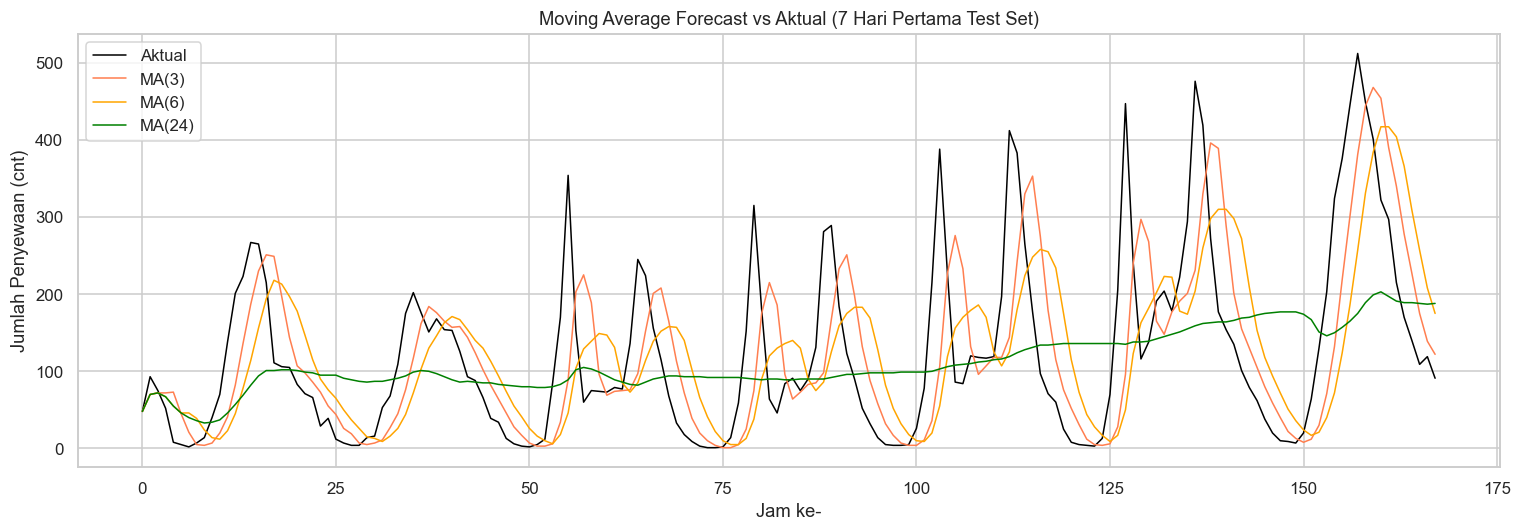

Grafik Moving Average tersimpan.


In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(hari_tampil), y_test[:hari_tampil], label='Aktual', color='black', linewidth=1)
ax.plot(range(hari_tampil), y_pred_ma3[:hari_tampil], label='MA(3)', color='coral', linewidth=1)
ax.plot(range(hari_tampil), y_pred_ma6[:hari_tampil], label='MA(6)', color='orange', linewidth=1)
ax.plot(range(hari_tampil), y_pred_ma24[:hari_tampil], label='MA(24)', color='green', linewidth=1)
ax.set_title('Moving Average Forecast vs Aktual (7 Hari Pertama Test Set)')
ax.set_xlabel('Jam ke-')
ax.set_ylabel('Jumlah Penyewaan (cnt)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/baseline_02_moving_avg.png', bbox_inches='tight', dpi=110)
plt.show()
print('Grafik Moving Average tersimpan.')

---

## 7. Seasonal Naive Forecast (Lag 24)

Seasonal Naive menggunakan nilai pada **jam yang sama kemarin** sebagai prediksi.

$$\hat{y}_{t} = y_{t-24}$$

In [9]:
# Seasonal Naive (lag 24) — menggunakan test set, baris awal diisi NaN lalu di-drop
y_pred_snaive = np.roll(y_test, 24)
y_pred_snaive[:24] = y_train[-24:]  # isi dengan train terakhir

metrik_snaive = hitung_metrik(y_test, y_pred_snaive, 'Seasonal Naive (Lag 24)')
print(pd.DataFrame([metrik_snaive]).to_string(index=False))

                  Model     MAE     RMSE    MAPE
Seasonal Naive (Lag 24) 77.6201 129.7157 78.2515


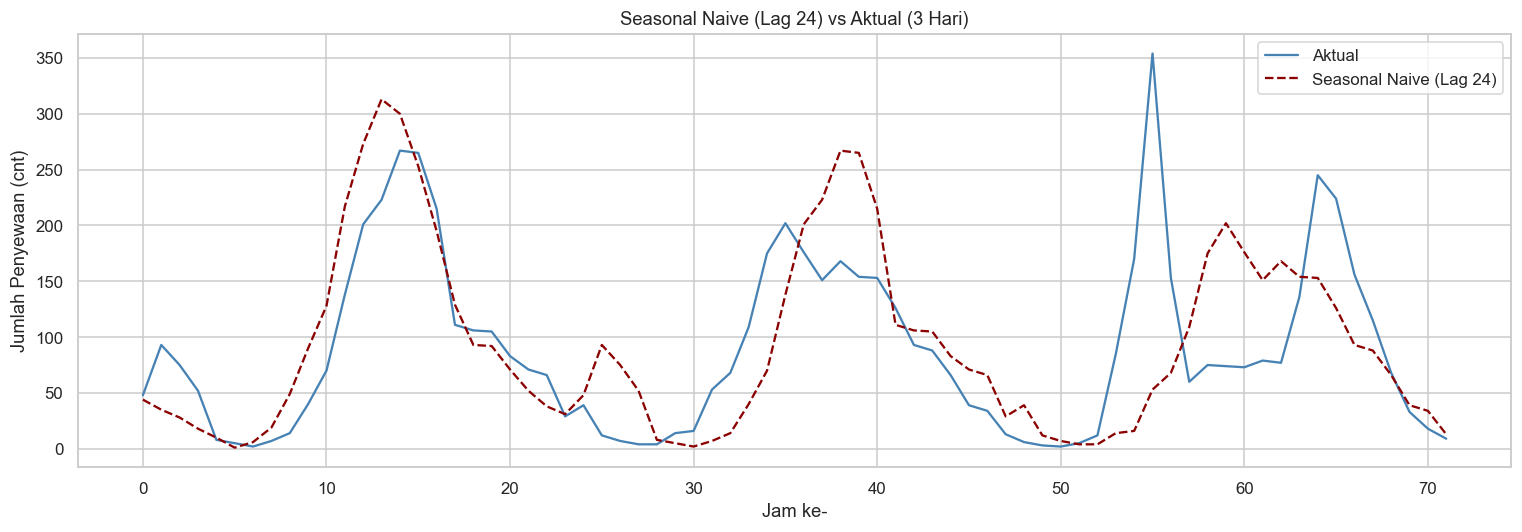

Grafik Seasonal Naive tersimpan.


In [10]:
# Visualisasi 3 hari untuk melihat pola kemarin vs hari ini
tiga_hari = 72

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(tiga_hari), y_test[:tiga_hari], label='Aktual', color='steelblue', linewidth=1.5)
ax.plot(range(tiga_hari), y_pred_snaive[:tiga_hari], label='Seasonal Naive (Lag 24)', color='darkred', linewidth=1.5, linestyle='--')
ax.set_title('Seasonal Naive (Lag 24) vs Aktual (3 Hari)')
ax.set_xlabel('Jam ke-')
ax.set_ylabel('Jumlah Penyewaan (cnt)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/baseline_03_seasonal_naive.png', bbox_inches='tight', dpi=110)
plt.show()
print('Grafik Seasonal Naive tersimpan.')

---

## 8. Perbandingan Baseline

In [11]:
df_metrik = pd.DataFrame([
    metrik_naive, metrik_snaive,
    metrik_ma3, metrik_ma6, metrik_ma24
])

print('=' * 65)
print('PERBANDINGAN BASELINE MODEL')
print('=' * 65)
print(df_metrik.to_string(index=False))

# Simpan hasil
df_metrik.to_csv('../data/baseline_metrics.csv', index=False)
print('\nHasil disimpan ke: ../data/baseline_metrics.csv')

PERBANDINGAN BASELINE MODEL
                  Model      MAE     RMSE     MAPE
         Naive Forecast  80.1782 121.5638  57.6021
Seasonal Naive (Lag 24)  77.6201 129.7157  78.2515
         Moving Avg (3) 121.5832 170.5283 124.3828
         Moving Avg (6) 154.1433 204.5584 291.8571
        Moving Avg (24) 156.5984 199.3650 652.7531

Hasil disimpan ke: ../data/baseline_metrics.csv


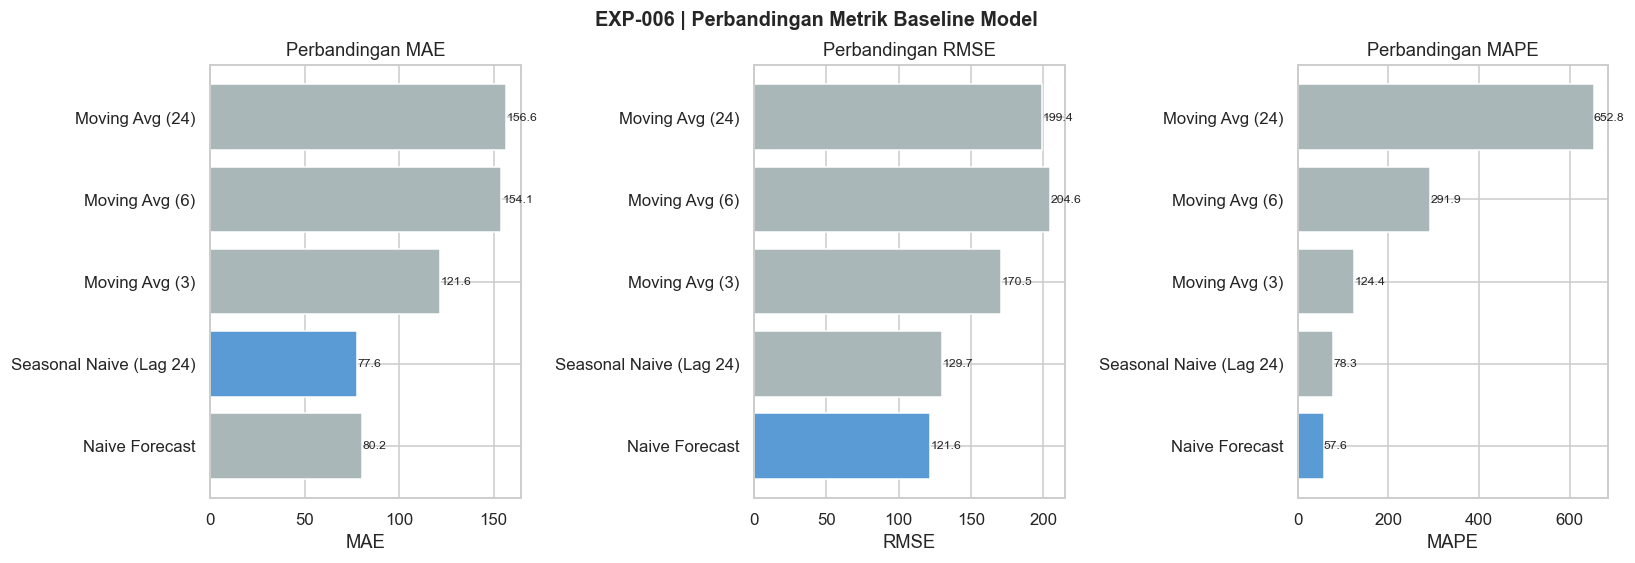

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, metrik in enumerate(['MAE', 'RMSE', 'MAPE']):
    colors = ['#5b9bd5' if v == df_metrik[metrik].min() else '#aab7b8' for v in df_metrik[metrik]]
    bars = axes[i].barh(df_metrik['Model'], df_metrik[metrik], color=colors, edgecolor='white')
    axes[i].set_title(f'Perbandingan {metrik}')
    axes[i].set_xlabel(metrik)
    for bar, val in zip(bars, df_metrik[metrik]):
        axes[i].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.suptitle('EXP-006 | Perbandingan Metrik Baseline Model', fontsize=13, y=1.02, fontweight='bold')
plt.savefig('../data/baseline_04_comparison.png', bbox_inches='tight', dpi=110)
plt.show()

---

## 9. Kesimpulan & Next Step

### Insight

- Model baseline dengan performa terbaik: **[Model dengan MAE/RMSE terendah]**
- Seasonal Naive (Lag 24) cenderung unggul karena data memiliki pola harian yang kuat.
- Moving Average dengan window kecil (3, 6) kurang optimal karena sensitif terhadap fluktuasi jangka pendek.

---

### Next Step

| Informasi | Detail |
|-----------|--------|
| **ID** | EXP-007 |
| **Nama** | Linear Regression |
| **Notebook** | `07_linear_regression.ipynb` |

---

*Notebook EXP-006 Baseline Forecasting — Selesai.*